/users/5/mulli468/.local/lib/python3.8/site-packages/pandas/core/computation/expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED



>>> Processing case1...


Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations


   Calculating SHAP for 200 points...
1/1 [==============================] - 0s 97ms/step


  0%|          | 0/200 [00:00<?, ?it/s]

...

Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations


   Calculating SHAP for 200 points...
1/1 [==============================] - 0s 83ms/step


  0%|          | 0/200 [00:00<?, ?it/s]

1573/1573 [==============================] - 1s 768us/step


1573/1573 [==============================] - 1s 784us/step

✅ DATA SAVED: 'shap_data_final/combined_shap_values.npy'
✅ DATA SAVED: 'shap_data_final/combined_features.csv'
✅ PLOT SAVED: 'plots/unified_shap_summary.png'


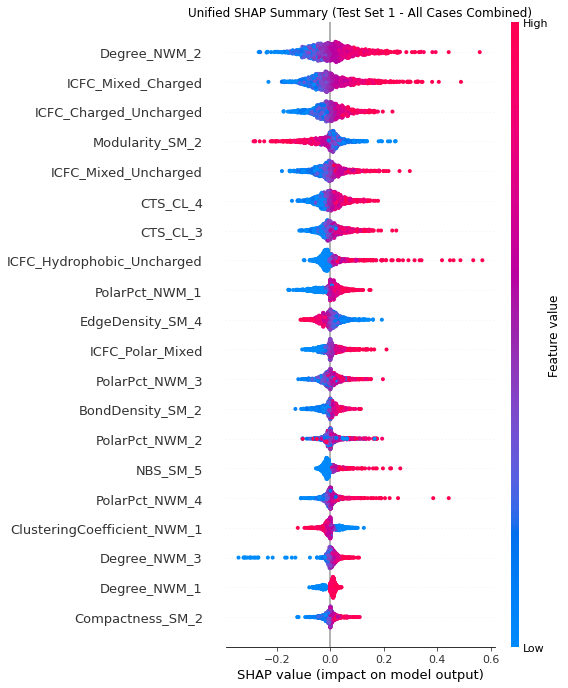

In [1]:
import shap
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
import joblib
import matplotlib.pyplot as plt
import os

# ---------------------------------------------------------
# 1. Hardcoded Model Architectures (Version-Safe)
# ---------------------------------------------------------
def rebuild_model(case_num, input_dim=294):
    """
    Rebuilds the exact architecture for each case to avoid 
    Keras deserialization/version errors.
    """
    model = Sequential()
    model.add(Input(shape=(input_dim,)))
    
    if case_num == 1:
        model.add(Dense(512, activation='relu'))
        model.add(Dropout(0.10017))
        model.add(Dense(32, activation='relu'))
        model.add(Dropout(0.10017))
        model.add(Dense(64, activation='relu'))
        model.add(Dense(1, activation='sigmoid'))
    
    elif case_num == 2:
        model.add(Dense(128, activation='relu'))
        model.add(BatchNormalization())
        model.add(Dropout(0.16416))
        model.add(Dense(512, activation='relu'))
        model.add(Dropout(0.16416))
        model.add(Dense(64, activation='relu'))
        model.add(BatchNormalization())
        model.add(Dense(512, activation='relu'))
        model.add(Dropout(0.16416))
        model.add(Dense(1, activation='sigmoid'))
        
    elif case_num == 3:
        model.add(Dense(256, activation='relu'))
        model.add(BatchNormalization())
        model.add(Dropout(0.45457))
        model.add(Dense(512, activation='relu'))
        model.add(BatchNormalization())
        model.add(Dense(128, activation='relu'))
        model.add(BatchNormalization())
        model.add(Dropout(0.45457))
        model.add(Dense(128, activation='relu'))
        model.add(BatchNormalization())
        model.add(Dropout(0.45457))
        model.add(Dense(512, activation='relu'))
        model.add(BatchNormalization())
        model.add(Dense(1, activation='sigmoid'))

    elif case_num == 4:
        model.add(Dense(512, activation='relu'))
        model.add(BatchNormalization())
        model.add(Dropout(0.28028))
        model.add(Dense(512, activation='relu'))
        model.add(BatchNormalization())
        model.add(Dense(64, activation='relu'))
        model.add(BatchNormalization())
        model.add(Dropout(0.28028))
        model.add(Dense(512, activation='relu'))
        model.add(Dropout(0.28028))
        model.add(Dense(1, activation='sigmoid'))

    elif case_num == 5:
        model.add(Dense(512, activation='relu'))
        model.add(BatchNormalization())
        model.add(Dropout(0.39304))
        model.add(Dense(512, activation='relu'))
        model.add(Dropout(0.39304))
        model.add(Dense(1, activation='sigmoid'))

    elif case_num == 6:
        model.add(Dense(512, activation='relu'))
        model.add(Dropout(0.15353))
        model.add(Dense(64, activation='relu'))
        model.add(BatchNormalization())
        model.add(Dense(128, activation='relu'))
        model.add(Dropout(0.15353))
        model.add(Dense(128, activation='relu'))
        model.add(BatchNormalization())
        model.add(Dense(16, activation='relu'))
        model.add(BatchNormalization())
        model.add(Dense(1, activation='sigmoid'))
        
    return model

# ---------------------------------------------------------
# 2. Settings & Folders
# ---------------------------------------------------------
GLOBAL_SEED = 42
N_POINTS_PER_CASE = 200 
all_shap_values = []
all_feature_data = []

# Ensure directories exist
os.makedirs('shap_data_final', exist_ok=True)
os.makedirs('plots', exist_ok=True)

# ---------------------------------------------------------
# 3. Execution Loop
# ---------------------------------------------------------
for i in range(1, 7):
    case_name = f"case{i}"
    print(f"\n>>> Processing {case_name}...")
    
    # Paths (adjust if files are named differently, e.g. final_model_case1.h5)
    data_path = f"{case_name}/set1_features.csv"
    model_path = f"{case_name}/models/final_model.h5" 
    scaler_path = f"{case_name}/models/final_scaler.gz"

    if not os.path.exists(data_path):
        print(f"Skipping {case_name}: Data file not found.")
        continue

    # 1. Load Data & Filter to Test Set 1
    df = pd.read_csv(data_path)
    metadata_cols = ['file', 'Family_Name', 'deltaG']
    feature_cols = [c for c in df.columns if c not in metadata_cols]
    
    test1_list = []
    for _, group in df.groupby('Family_Name'):
        if len(group) >= 2:
            grp_shuffled = group.sample(frac=1, random_state=GLOBAL_SEED)
            split_point = int(len(grp_shuffled) * 0.8)
            test1_list.append(grp_shuffled.iloc[split_point:])
    test1_df = pd.concat(test1_list).reset_index(drop=True)

    # 2. Rebuild and Load Weights
    model = rebuild_model(i, input_dim=len(feature_cols))
    model.load_weights(model_path)
    scaler = joblib.load(scaler_path)

    # 3. Scale and Sample
    X_raw = test1_df[feature_cols].values
    X_scaled = scaler.transform(X_raw)
    X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)
    
    n_sample = min(N_POINTS_PER_CASE, len(X_scaled_df))
    subset = X_scaled_df.sample(n=n_sample, random_state=GLOBAL_SEED)

    # 4. Compute SHAP Values
    print(f"   Calculating SHAP for {n_sample} points...")
    # Use kmeans background to speed up KernelExplainer significantly
    background = shap.kmeans(X_scaled_df, 20)
    explainer = shap.KernelExplainer(model.predict, background)
    shap_vals = explainer.shap_values(subset)

    # Handle dimension inconsistencies in SHAP output
    if isinstance(shap_vals, list): shap_vals = shap_vals[0]
    if len(shap_vals.shape) == 3: shap_vals = np.squeeze(shap_vals)
    
    all_shap_values.append(shap_vals)
    all_feature_data.append(subset)

# ---------------------------------------------------------
# 4. Save Analysis Data (The "Don't Run Again" Part)
# ---------------------------------------------------------
if all_shap_values:
    final_shap_array = np.concatenate(all_shap_values, axis=0)
    final_features_df = pd.concat(all_feature_data, axis=0).reset_index(drop=True)

    # Save to disk
    np.save('shap_data_final/combined_shap_values.npy', final_shap_array)
    final_features_df.to_csv('shap_data_final/combined_features.csv', index=False)
    
    print("\n✅ DATA SAVED: 'shap_data_final/combined_shap_values.npy'")
    print("✅ DATA SAVED: 'shap_data_final/combined_features.csv'")

    # 5. Generate and Save Final Plot
    plt.figure(figsize=(12, 10))
    shap.summary_plot(final_shap_array, final_features_df, show=False)
    plt.title("Unified SHAP Summary (Test Set 1 - All Cases Combined)")
    
    plot_path = 'plots/unified_shap_summary.png'
    plt.savefig(plot_path, bbox_inches='tight', dpi=300)
    print(f"✅ PLOT SAVED: '{plot_path}'")
else:
    print("No data was processed.")

In [9]:
import pandas as pd
import numpy as np
import os

def get_feature_category(name):
    # 1. Connectivity Based (Purely topological/graph-theory metrics)
    connectivity_prefixes = [
        'Degree_NWM_', 'ClusteringCoefficient_NWM_', 'BetweennessCentrality_NWM_',
        'EigenCentrality_NWM_', 'PageRank_NWM_', 'KCoreDecomposition_NWM_',
        'CBC_NWM_', 'Modularity_SM_', 'EdgeDensity_SM_',
        'Compactness_SM_', 'BondDensity_SM_', 'AlgebraicConnectivity_SM_',
        'ICBF_', 'CTO_', 'ICFC_', 
        'NBS_SM_', 'PTDC_SM_', 'ParatopeRatio_NWM_', 'GR_SM_'
    ]

    # 2. Geometry Based (Purely spatial metrics within a single coordinate system)
    geometry_prefixes = [
        'TPED_VWM_', 'CTS_CL_', 'CSH_CL_', 'CSD_CL_', 'ICPZ_CL_'
    ]

    # 3. Projection Based (Hybrid metrics: Spring vs PDB OR Connectivity vs Spatial)
    # Added NRF, CCR, TDF, CICS here because they use dual-network or dual-logic comparisons
    projection_prefixes = [
        'ConvexHullVolume_VWM_', 'Spread_VWM_', 'AveragePairwiseDistance_VWM_',
        'SpatialClusteringCoefficient_VWM_', 'ProximityCentralization_VWM_',
        'WAI_VWM_', 'STC_VWM_', 'ZCent_SM_', 
        'CentroidX_', 'CentroidY_', 'CentroidZ_', 'WICDS',
        'TFD_VWM_', 'WSAVR_VWM_', 
        'NRF_VWM_', 'CCR_VWM_', 'TDF_VWM_', 'CICS_SM_' 
    ]

    # 4. Others
    others_prefixes = ['PolarPct_NWM_']

    # --- Hierarchy Logic ---
    # We check Projection FIRST because it acts as the "Catch-all" for hybrid features
    if any(name.startswith(pre) for pre in projection_prefixes):
        return "Projection Based"
    
    if any(name.startswith(pre) for pre in connectivity_prefixes):
        return "Connectivity Based"
    
    if any(name.startswith(pre) for pre in geometry_prefixes):
        return "Geometry Based"
    
    if any(name.startswith(pre) for pre in others_prefixes):
        return "Others"

    return "Uncategorized/Metadata"

# ---------------------------------------------------------
# 2. Data Loading & SHAP Importance Calculation
# ---------------------------------------------------------
shap_vals_path = 'shap_data_final/combined_shap_values.npy'
features_path = 'shap_data_final/combined_features.csv'

if os.path.exists(shap_vals_path) and os.path.exists(features_path):
    # Load SHAP values and feature names
    shap_values = np.load(shap_vals_path)
    features_df = pd.read_csv(features_path)

    # Standardize SHAP shape (assuming multi-sample or multi-class output)
    # Calculate Mean Absolute SHAP Value (Global Importance)
    vals = shap_values[0] if isinstance(shap_values, list) else shap_values
    if len(vals.shape) == 3:
        # If (samples, features, outputs), average across samples and outputs
        feature_importance = np.abs(vals).mean(axis=(0, 2))
    elif len(vals.shape) == 2:
        # If (samples, features)
        feature_importance = np.abs(vals).mean(axis=0)
    else:
        feature_importance = np.abs(vals)

    # Create Importance DataFrame
    df_importance = pd.DataFrame({
        'Feature': features_df.columns,
        'Importance': feature_importance
    })

    # Apply categorization
    df_importance['Category'] = df_importance['Feature'].apply(get_feature_category)

    # ---------------------------------------------------------
    # 3. Aggregation & Metrics
    # ---------------------------------------------------------
    category_summary = df_importance.groupby('Category').agg(
        Feature_Count=('Feature', 'count'),
        Total_Importance=('Importance', 'sum'),
        Avg_Importance_Per_Feature=('Importance', 'mean')
    ).sort_values(by='Total_Importance', ascending=False)

    # Calculate Importance Share (%)
    total_shap_sum = category_summary['Total_Importance'].sum()
    category_summary['Importance_Share (%)'] = (category_summary['Total_Importance'] / total_shap_sum) * 100

    # ---------------------------------------------------------
    # 4. Display Results
    # ---------------------------------------------------------
    print("\n" + "="*80)
    print(f"{'PIPELINE STAGE BREAKDOWN (SHAP)':^80}")
    print("="*80)
    # Formatting for terminal display
    display_cols = ['Feature_Count', 'Importance_Share (%)']
    print(category_summary[display_cols].round(4).to_string())
    print("="*80)

    # --- Audit: Identify any remaining uncategorized features ---
    uncat_df = df_importance[df_importance['Category'] == "Uncategorized/Metadata"]
    # We ignore the 'file' or 'target' column if they are present in the CSV
    metadata_cols = ['file', 'Unnamed: 0', 'target']
    true_uncat = uncat_df[~uncat_df['Feature'].isin(metadata_cols)]

    if not true_uncat.empty:
        print(f"\nALERT: {len(true_uncat)} true features remain uncategorized:")
        for feat in true_uncat['Feature'].tolist():
            print(f" - {feat}")
    else:
        print("\nSUCCESS: All structural features successfully categorized.")

else:
    print(f"Error: Required files not found at {shap_vals_path} or {features_path}")


                        PIPELINE STAGE BREAKDOWN (SHAP)                         
                    Feature_Count  Importance_Share (%)
Category                                               
Connectivity Based            141               58.9472
Projection Based              117               24.7203
Geometry Based                 30               10.7785
Others                          6                5.5540

SUCCESS: All structural features successfully categorized.


In [11]:
import pandas as pd
import numpy as np
import os

# ---------------------------------------------------------
# 1. Subnetwork-Based Categorization Logic
# ---------------------------------------------------------
def get_subnetwork_category(name):
    """
    Categorizes features by their subnetwork index (_0 to _5).
    Features without these indices are grouped as 'Chemical/Interaction'.
    """
    # Check for the specific subnetwork suffixes
    for i in range(6):
        suffix = f"_{i}"
        # We check if suffix is in the name, 
        # specifically ensuring it's the subnetwork digit
        if suffix in name:
            return f"Subnetwork {i}"
    
    # If no _0 through _5 is found, it belongs to the global interaction features
    return "inter-subnetwork"

# ---------------------------------------------------------
# 2. Load Saved Data
# ---------------------------------------------------------
shap_vals_path = 'shap_data_final/combined_shap_values.npy'
features_path = 'shap_data_final/combined_features.csv'

if os.path.exists(shap_vals_path) and os.path.exists(features_path):
    shap_values = np.load(shap_vals_path)
    features_df = pd.read_csv(features_path)

    # ---------------------------------------------------------
    # 3. Calculate Importance & Share
    # ---------------------------------------------------------
    # Standardize SHAP values to 2D
    vals = shap_values[0] if isinstance(shap_values, list) else shap_values
    if len(vals.shape) == 3:
        vals = np.abs(vals).mean(axis=0)
    
    feature_importance = np.abs(vals).mean(axis=0)

    df_importance = pd.DataFrame({
        'Feature': features_df.columns,
        'Importance': feature_importance
    })

    # Apply the subnetwork-based categorization
    df_importance['Category'] = df_importance['Feature'].apply(get_subnetwork_category)

    # Grouping and Scoring
    category_summary = df_importance.groupby('Category').agg(
        Feature_Count=('Feature', 'count'),
        Total_Importance=('Importance', 'sum'),
        Avg_Importance_Per_Feature=('Importance', 'mean')
    ).sort_values(by='Category') # Sort by Subnetwork 0, 1, 2...

    # Calculate Share (%)
    total_shap_sum = category_summary['Total_Importance'].sum()
    category_summary['Importance_Share (%)'] = (category_summary['Total_Importance'] / total_shap_sum) * 100

    # ---------------------------------------------------------
    # 4. Display Results
    # ---------------------------------------------------------
    print("\n" + "="*70)
    print(f"{'SUBNETWORK IMPORTANCE BREAKDOWN (_0 to _5)':^70}")
    print("="*70)
    
    output_table = category_summary[['Feature_Count', 'Importance_Share (%)']]
    print(output_table.round(4))
    print("="*70)
    
else:
    print("Error: Saved data files not found.")


              SUBNETWORK IMPORTANCE BREAKDOWN (_0 to _5)              
                  Feature_Count  Importance_Share (%)
Category                                             
Subnetwork 0                 39               10.4596
Subnetwork 1                 39               11.6138
Subnetwork 2                 39               17.7348
Subnetwork 3                 39               13.6821
Subnetwork 4                 39               13.1096
Subnetwork 5                 39                8.1194
inter-subnetwork             60               25.2807


In [12]:
import pandas as pd
import numpy as np
import os

# ---------------------------------------------------------
# 1. Intra vs Inter Subnetwork Categorization Logic
# ---------------------------------------------------------
def get_detailed_category(name):
    """
    Categorizes features into Intra-subnetwork (local topology) 
    or Inter-subnetwork (chemical interactions).
    """
    # 1. Check for Intra-subnetwork suffixes (_0 to _5)
    # These represent the individual topological slices
    intra_suffixes = ['_0', '_1', '_2', '_3', '_4', '_5']
    if any(suffix in name for suffix in intra_suffixes):
        return "Intra-subnetwork"

    # 2. Check for Inter-subnetwork patterns
    # These represent chemical/physical interactions between residue types
    # (e.g., Hydrophobic_Polar, Charged_Flexible)
    inter_keywords = [
        'Hydrophobic', 'Polar', 'Mixed', 'Charged', 
        'Uncharged', 'Flexible', 'ICBF', 'ICFC', 'WICDS', 'CTO'
    ]
    if any(key in name for key in inter_keywords):
        return "Inter-subnetwork"

    return "Other/Metadata"

# ---------------------------------------------------------
# 2. Load Saved Data
# ---------------------------------------------------------
shap_vals_path = 'shap_data_final/combined_shap_values.npy'
features_path = 'shap_data_final/combined_features.csv'

if os.path.exists(shap_vals_path) and os.path.exists(features_path):
    # Load pre-calculated SHAP data
    shap_values = np.load(shap_vals_path)
    features_df = pd.read_csv(features_path)

    # ---------------------------------------------------------
    # 3. Calculate Importance & Share
    # ---------------------------------------------------------
    # Handle SHAP output (standardizing to mean absolute impact)
    vals = shap_values[0] if isinstance(shap_values, list) else shap_values
    if len(vals.shape) == 3:
        # If the array is (samples, features, outputs), mean across samples
        vals = np.abs(vals).mean(axis=0)
    
    feature_importance = np.abs(vals).mean(axis=0)

    df_importance = pd.DataFrame({
        'Feature': features_df.columns,
        'Importance': feature_importance
    })

    # Apply the Intra/Inter categorization
    df_importance['Category'] = df_importance['Feature'].apply(get_detailed_category)

    # Grouping and Scoring
    category_summary = df_importance.groupby('Category').agg(
        Feature_Count=('Feature', 'count'),
        Total_Importance=('Importance', 'sum'),
        Avg_Importance_Per_Feature=('Importance', 'mean')
    ).sort_values(by='Total_Importance', ascending=False)

    # Calculate Share (%)
    total_shap_sum = category_summary['Total_Importance'].sum()
    category_summary['Importance_Share (%)'] = (category_summary['Total_Importance'] / total_shap_sum) * 100

    # ---------------------------------------------------------
    # 4. Display Results
    # ---------------------------------------------------------
    print("\n" + "="*75)
    print(f"{'INTRA VS INTER SUBNETWORK ANALYSIS':^75}")
    print("="*75)
    
    # Reordering columns for final output
    final_table = category_summary[['Feature_Count', 'Importance_Share (%)']]
    print(final_table.round(4))
    print("="*75)
    
    # Validation Print
    print(f"Total Features Analyzed: {len(df_importance)}")

else:
    print(f"Error: Required files not found at {shap_vals_path} or {features_path}.")


                    INTRA VS INTER SUBNETWORK ANALYSIS                     
                  Feature_Count  Importance_Share (%)
Category                                             
Intra-subnetwork            234               74.7193
Inter-subnetwork             60               25.2807
Total Features Analyzed: 294


# Plots

## Geomerty, connectivity, projection


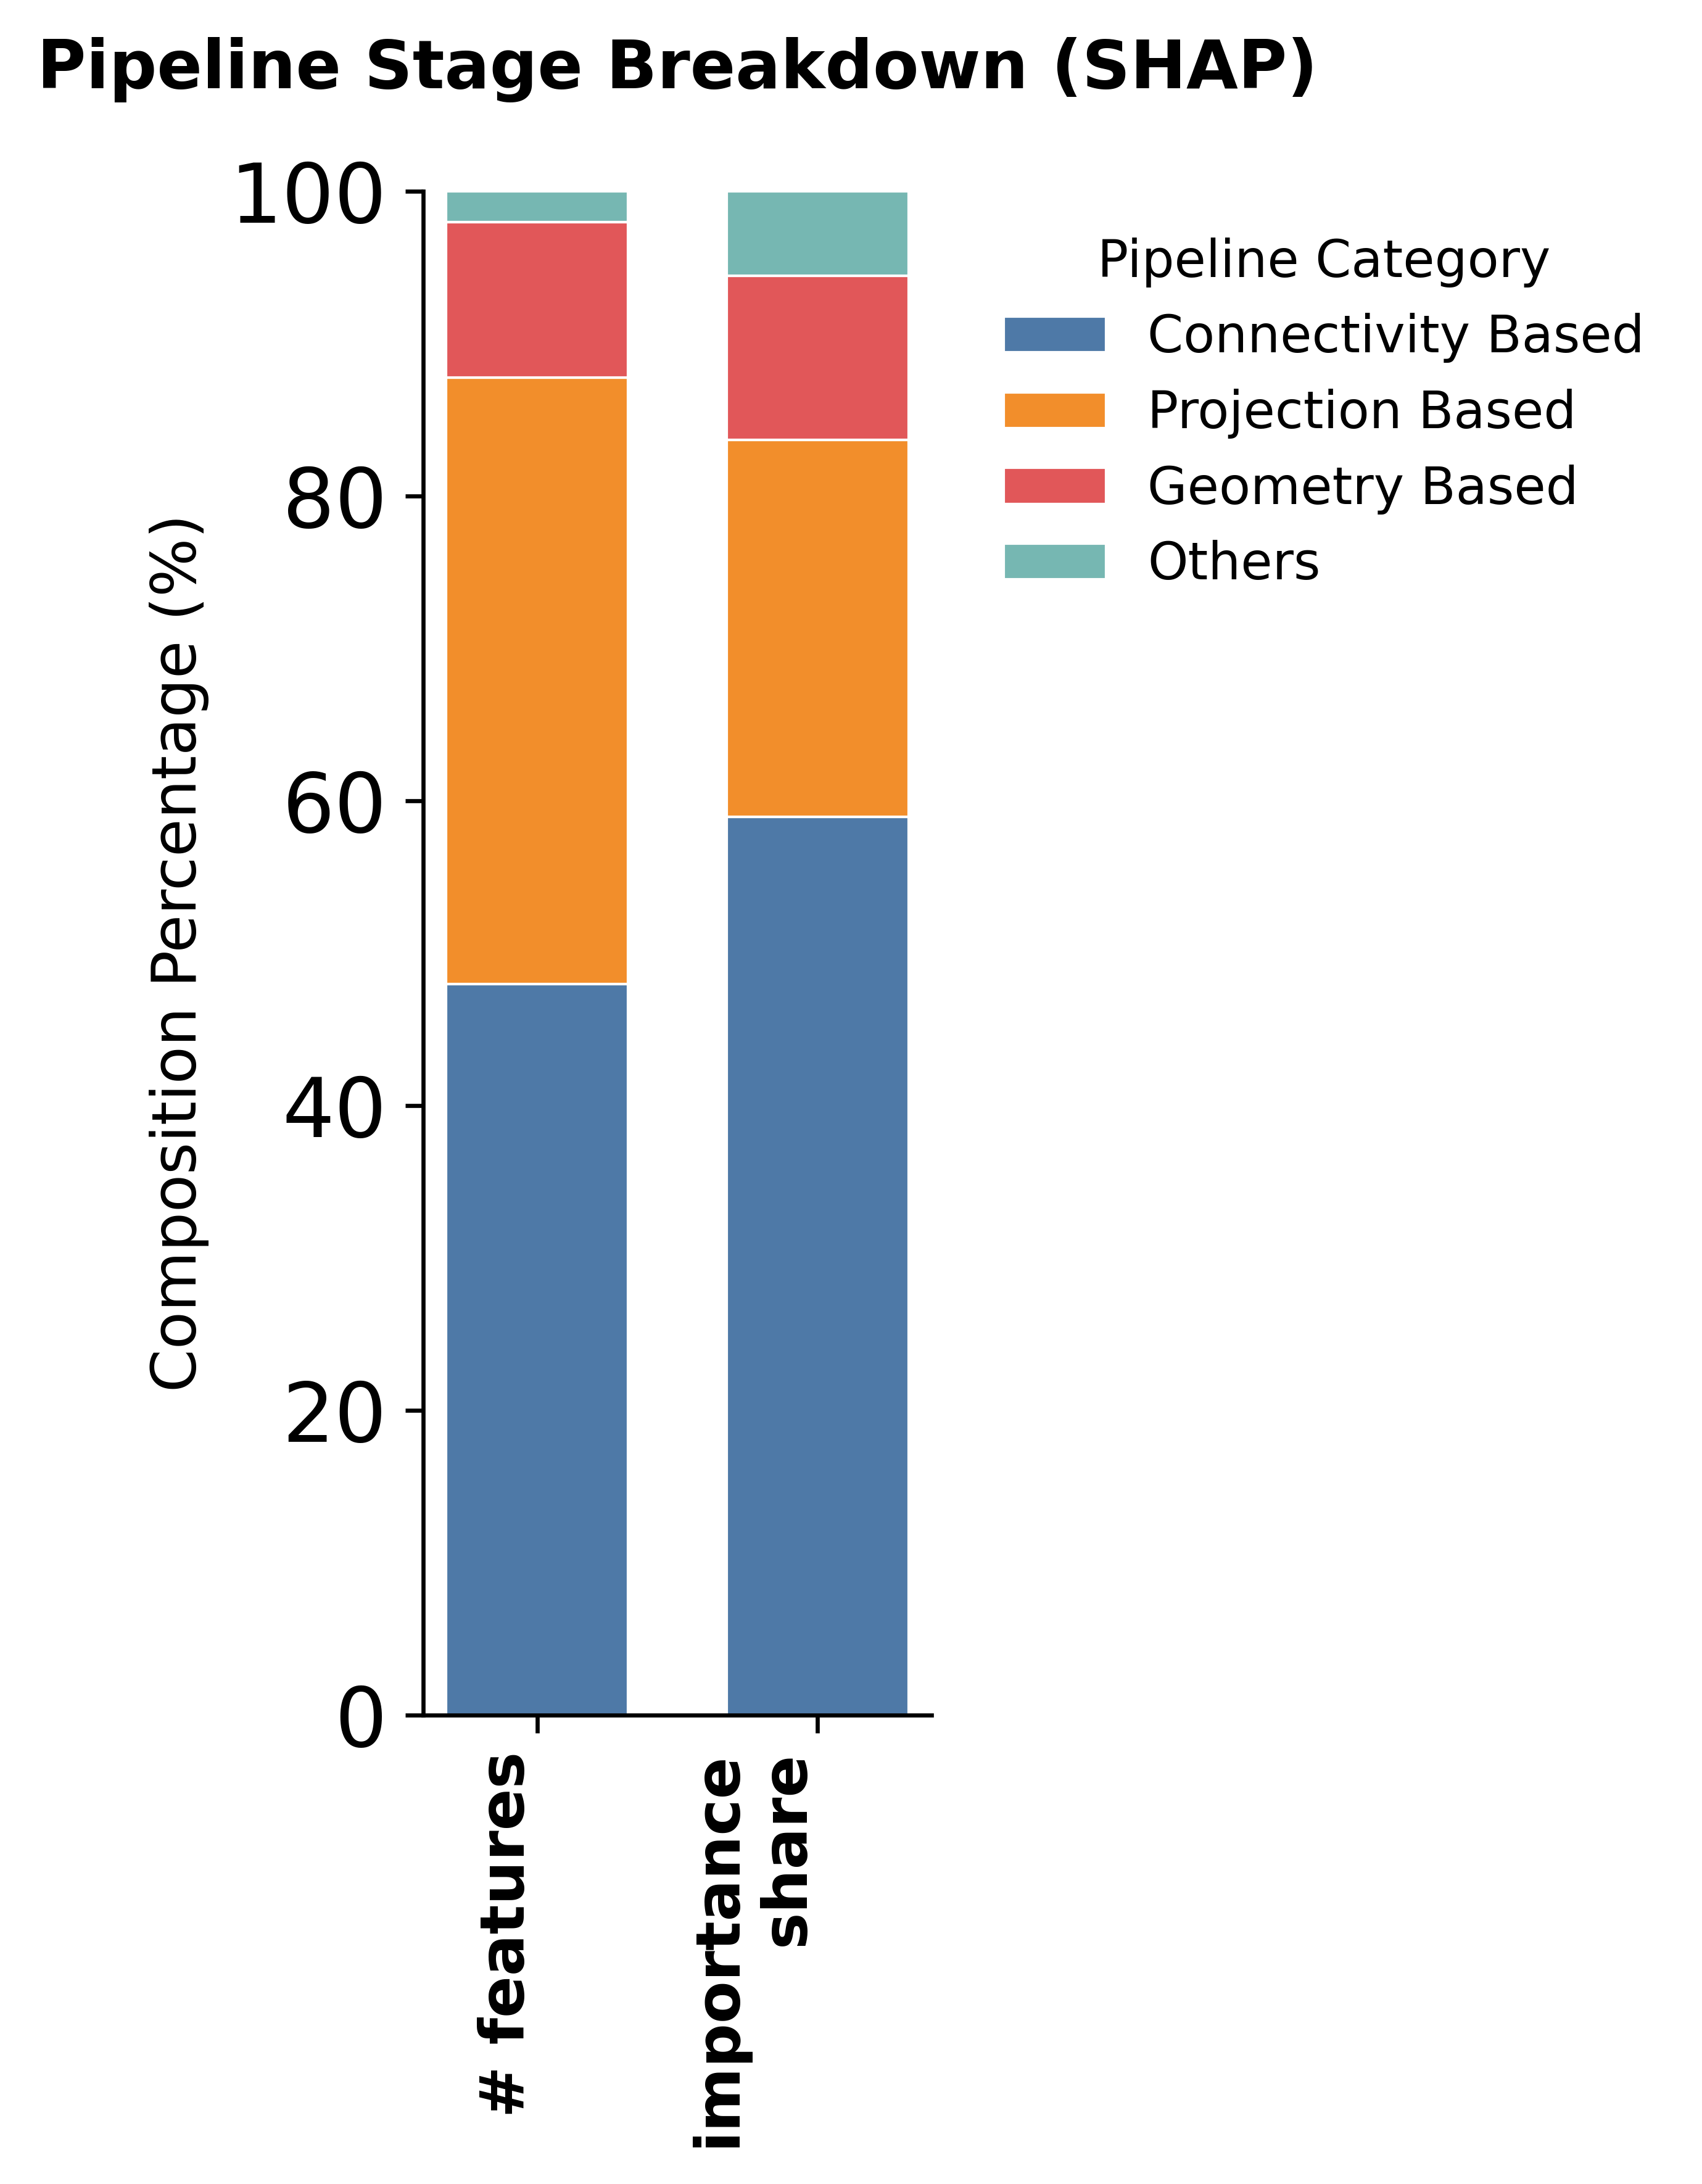

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Data Preparation
data = {
    'Category': ['Connectivity Based', 'Projection Based', 'Geometry Based', 'Others'],
    'Feature_Count': [141, 117, 30, 6],
    'Importance_Share (%)': [58.9472, 24.7203, 10.7785, 5.5540]
}

df = pd.DataFrame(data)

# Calculate Percentage Share for Feature Count (to compare relative proportions)
df['Feature_Share (%)'] = (df['Feature_Count'] / df['Feature_Count'].sum()) * 100

# 2. Plotting Setup (PNAS Style: Sans-serif, Clean Spines)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['axes.linewidth'] = 0.8

fig, ax = plt.subplots(figsize=(4.5, 6), dpi=600)

# High-quality Color Palette (Bio-publication inspired)
colors = ['#4E79A7', '#F28E2B', '#E15759', '#76B7B2']

categories = df['Category'].tolist()
bar_width = 0.65
bottom_feat = 0
bottom_imp = 0

# 3. Construct Stacked Bars
for i, category in enumerate(categories):
    feat_val = df.loc[i, 'Feature_Share (%)']
    imp_val = df.loc[i, 'Importance_Share (%)']
    
    # Left Bar: Feature Quantity Share
    ax.bar(0, feat_val, bottom=bottom_feat, width=bar_width, color=colors[i], 
           edgecolor='white', linewidth=0.5, label=category)
    
    # Right Bar: Importance Contribution Share
    ax.bar(1, imp_val, bottom=bottom_imp, width=bar_width, color=colors[i], 
           edgecolor='white', linewidth=0.5)
    
    # Update stack bottoms
    bottom_feat += feat_val
    bottom_imp += imp_val

# 4. Styling and Aesthetics
ax.set_xticks([0, 1])
ax.set_xticklabels(['# features', 'importance\nshare'], 
                    fontsize=12, 
                    fontweight='bold', 
                    rotation=90, 
                    ha='right')
ax.set_ylabel('Composition Percentage (%)', fontsize=12)
ax.set_ylim(0, 100)
ax.tick_params(axis='y', labelsize=16)
# Remove top and right spines for publication-ready look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add a professional title
plt.title('Pipeline Stage Breakdown (SHAP)', fontsize=13, pad=20, fontweight='bold')

# External Legend - Clean and without frame
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title='Pipeline Category', title_fontsize=10,
          bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)

plt.tight_layout()
#plt.savefig('pipeline_breakdown_clean.png', bbox_inches='tight')
plt.show()

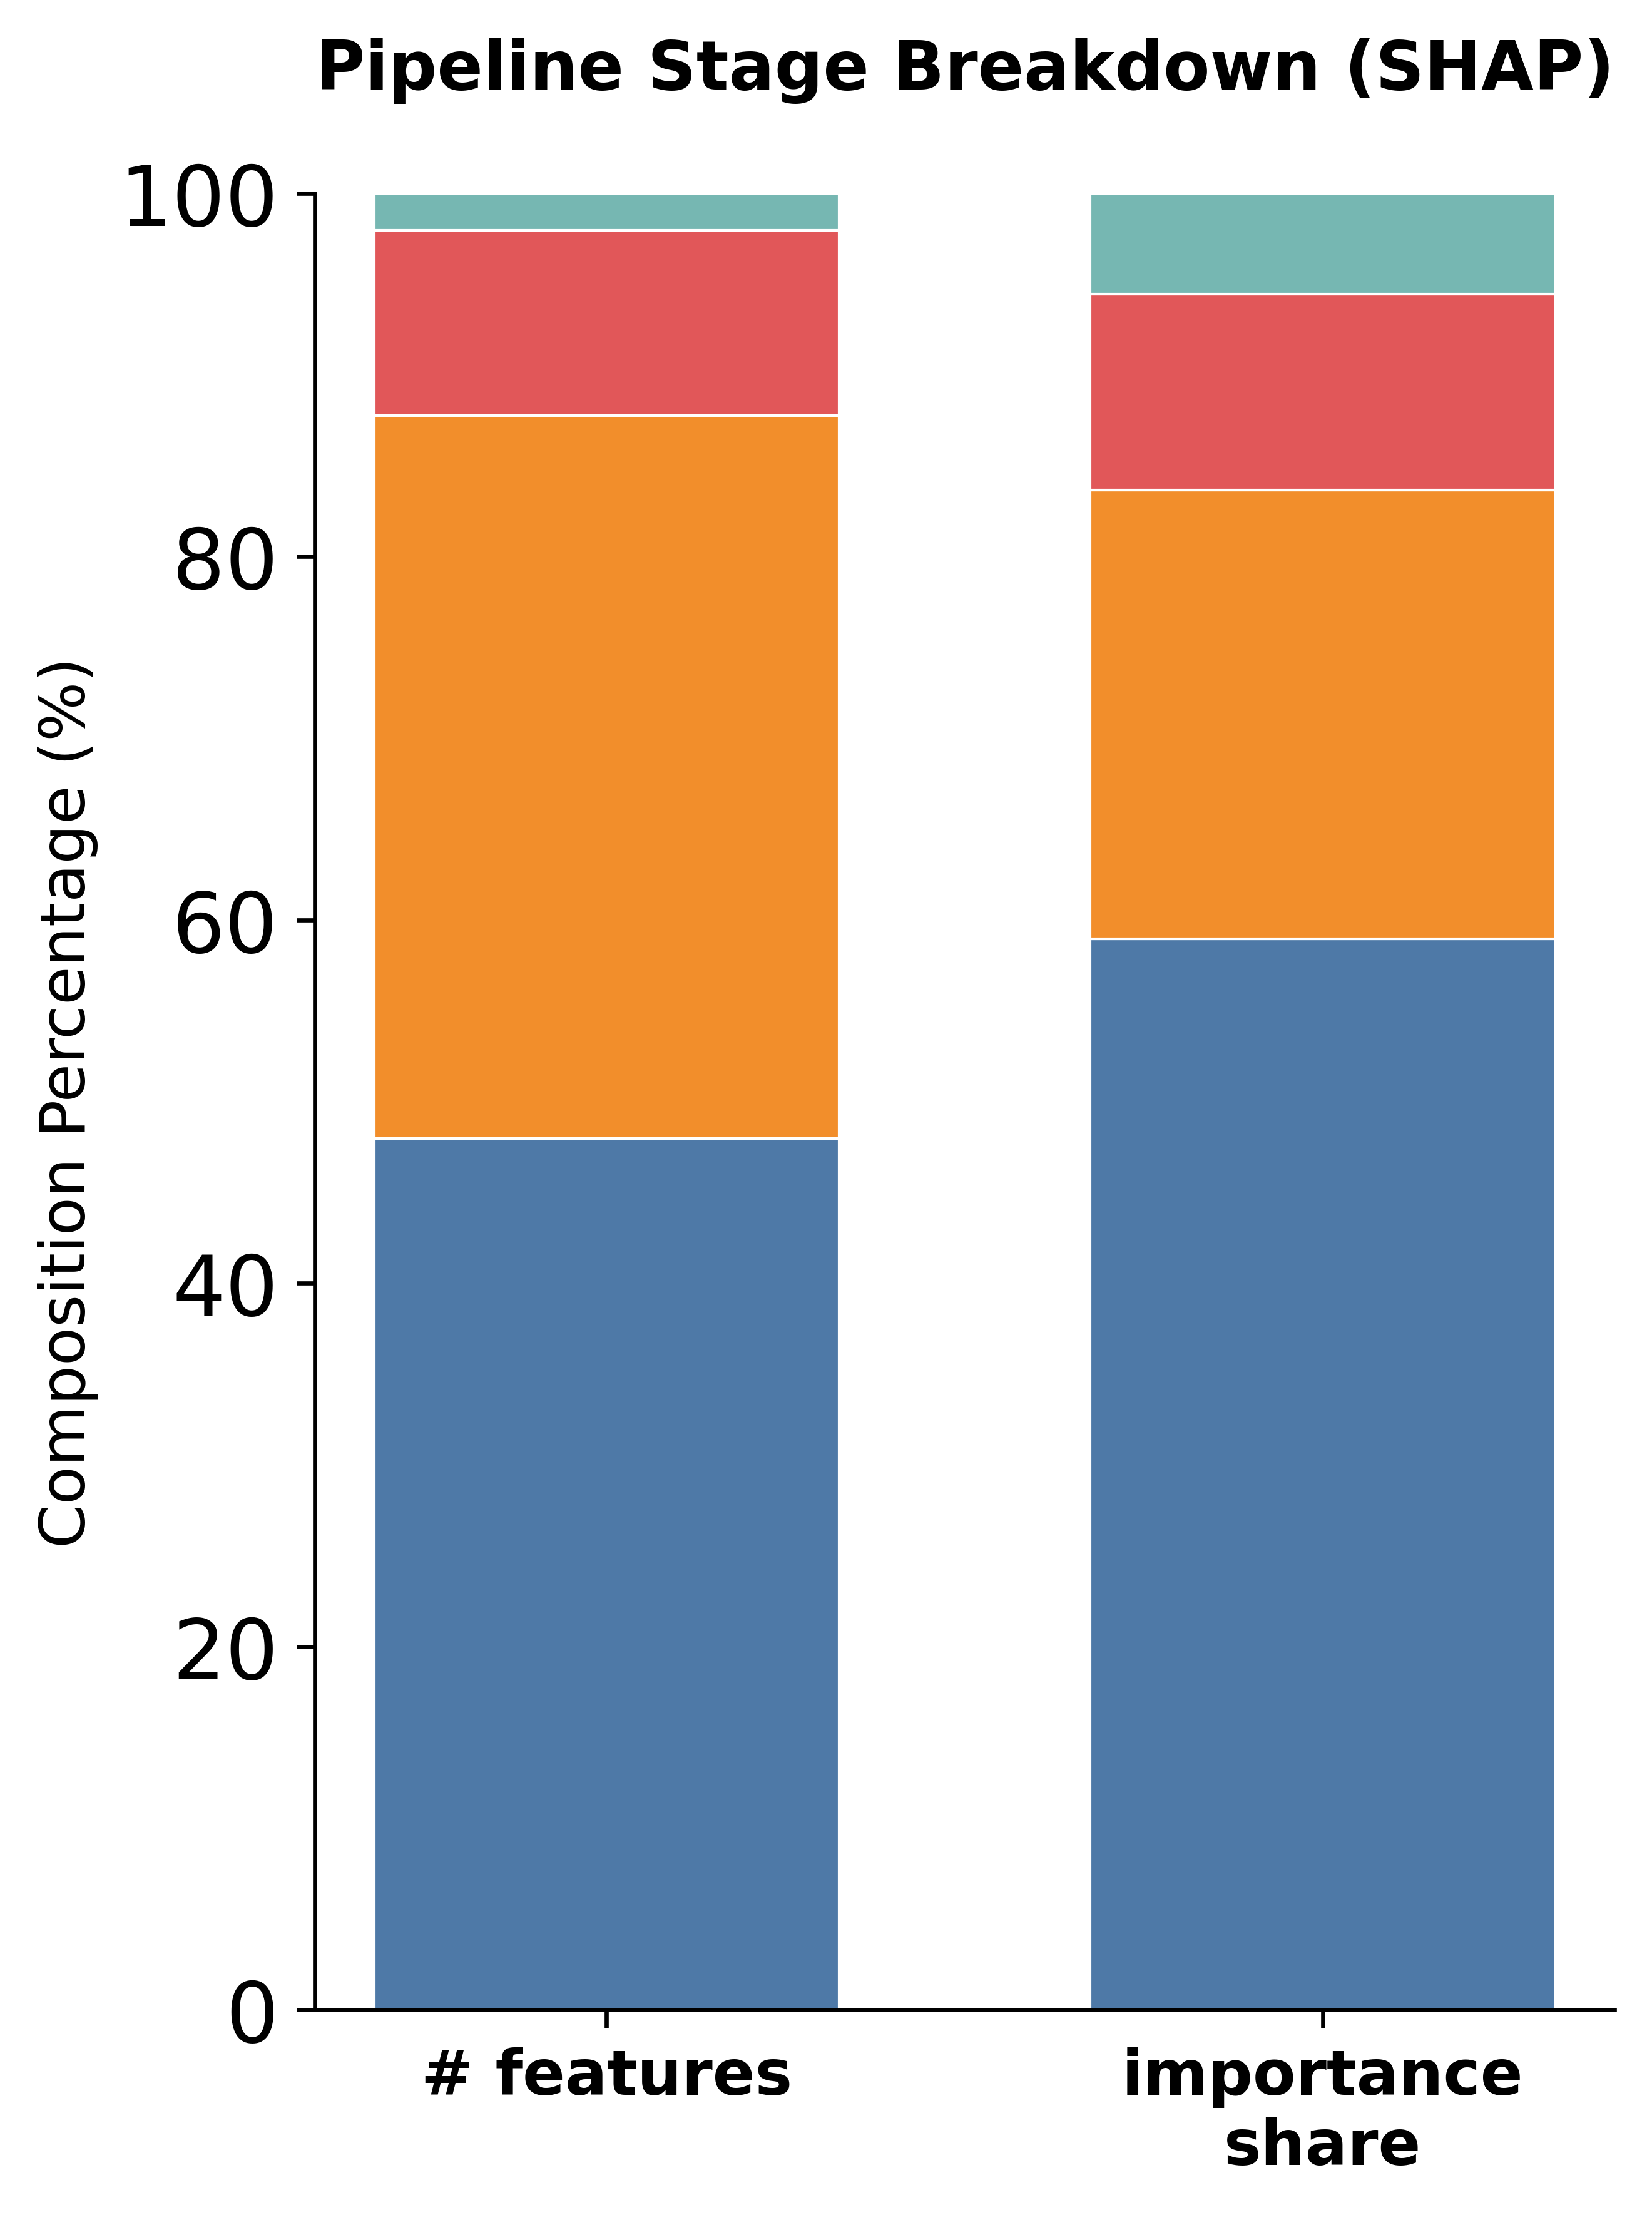

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Data Preparation
data = {
    'Category': ['Connectivity Based', 'Projection Based', 'Geometry Based', 'Others'],
    'Feature_Count': [141, 117, 30, 6],
    'Importance_Share (%)': [58.9472, 24.7203, 10.7785, 5.5540]
}

df = pd.DataFrame(data)

# Calculate Percentage Share for Feature Count (to compare relative proportions)
df['Feature_Share (%)'] = (df['Feature_Count'] / df['Feature_Count'].sum()) * 100

# 2. Plotting Setup (PNAS Style: Sans-serif, Clean Spines)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['axes.linewidth'] = 0.8

fig, ax = plt.subplots(figsize=(4.5, 6), dpi=600)

# High-quality Color Palette (Bio-publication inspired)
colors = ['#4E79A7', '#F28E2B', '#E15759', '#76B7B2']

categories = df['Category'].tolist()
bar_width = 0.65
bottom_feat = 0
bottom_imp = 0

# 3. Construct Stacked Bars
for i, category in enumerate(categories):
    feat_val = df.loc[i, 'Feature_Share (%)']
    imp_val = df.loc[i, 'Importance_Share (%)']
    
    # Left Bar: Feature Quantity Share
    ax.bar(0, feat_val, bottom=bottom_feat, width=bar_width, color=colors[i], 
           edgecolor='white', linewidth=0.5, label=category)
    
    # Right Bar: Importance Contribution Share
    ax.bar(1, imp_val, bottom=bottom_imp, width=bar_width, color=colors[i], 
           edgecolor='white', linewidth=0.5)
    
    # Update stack bottoms
    bottom_feat += feat_val
    bottom_imp += imp_val

# 4. Styling and Aesthetics
ax.set_xticks([0, 1])
ax.set_xticklabels(['# features', 'importance\nshare'], 
                    fontsize=12, 
                    fontweight='bold', 
                    rotation=0, 
                    ha='center')
ax.set_ylabel('Composition Percentage (%)', fontsize=12)
ax.set_ylim(0, 100)
ax.tick_params(axis='y', labelsize=16)
# Remove top and right spines for publication-ready look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add a professional title
plt.title('Pipeline Stage Breakdown (SHAP)', fontsize=13, pad=20, fontweight='bold')

# External Legend - Clean and without frame
handles, labels = ax.get_legend_handles_labels()


plt.tight_layout()
#plt.savefig('pipeline_breakdown_clean.png', bbox_inches='tight')
plt.show()

## inter vs intra subnetwork

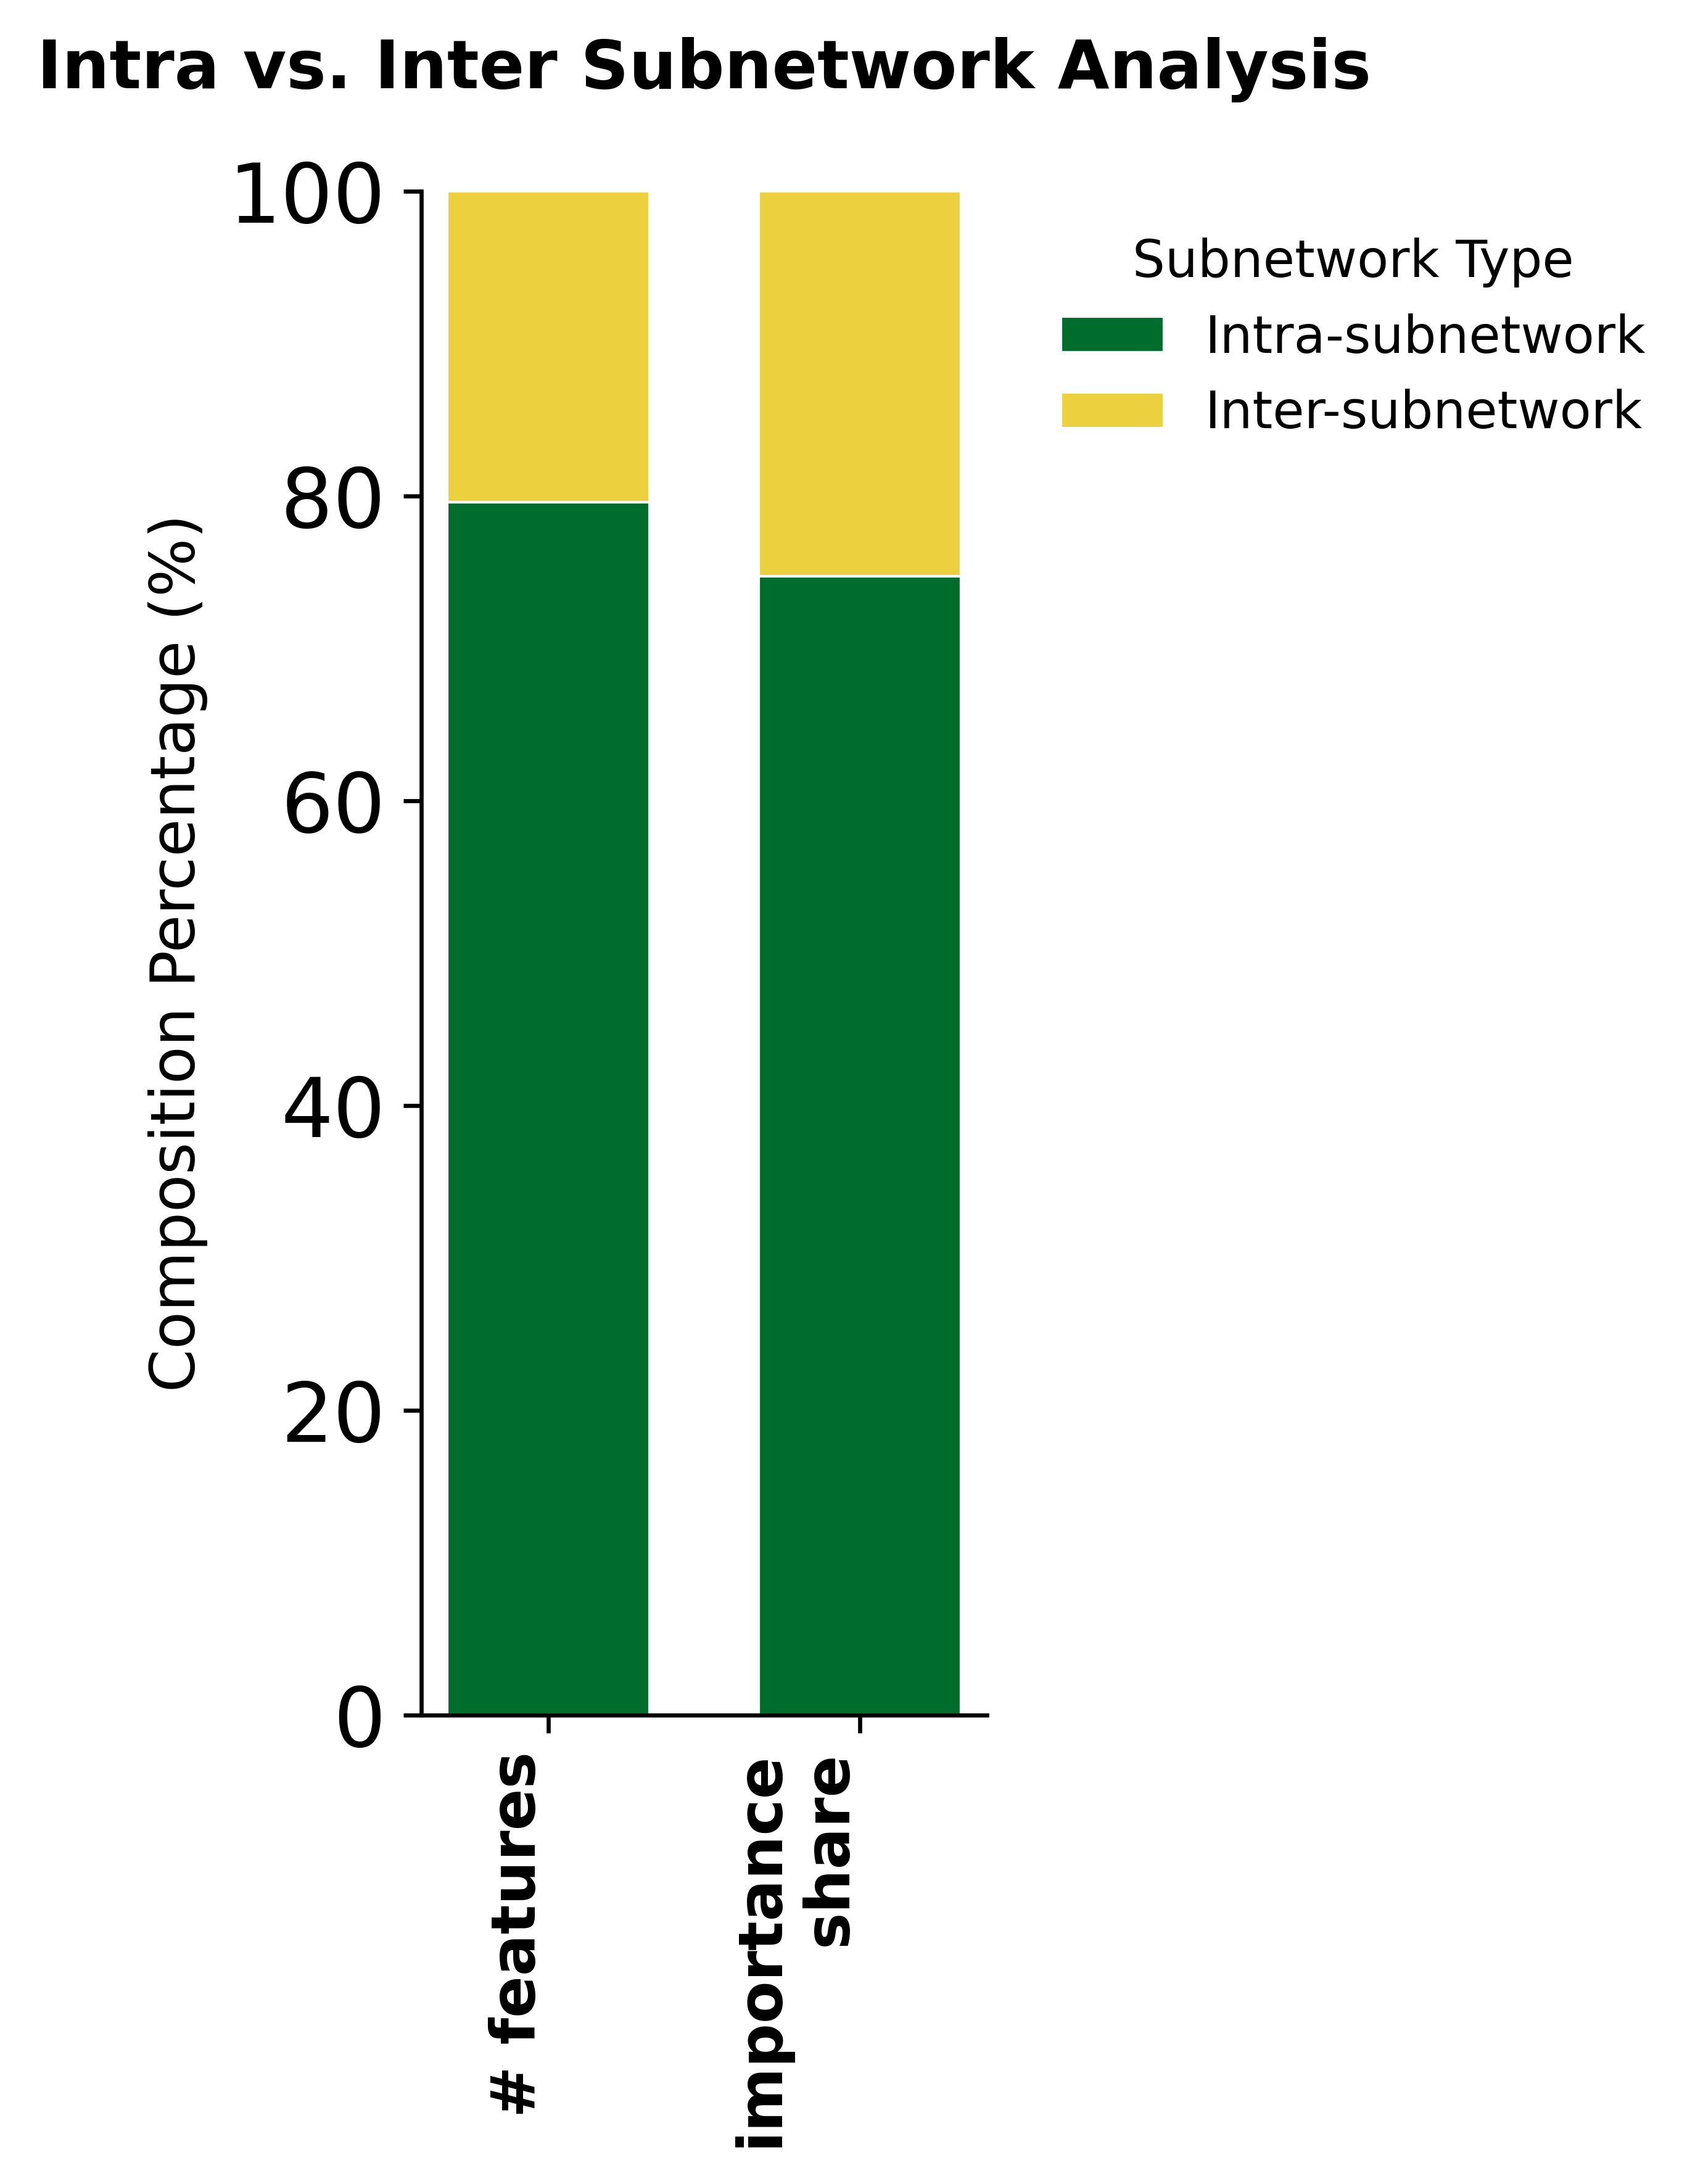

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Data Preparation
data = {
    'Category': ['Intra-subnetwork', 'Inter-subnetwork'],
    'Feature_Count': [234, 60],
    'Importance_Share (%)': [74.7193, 25.2807]
}

df = pd.DataFrame(data)

# Calculate Percentage Share for Feature Count
df['Feature_Share (%)'] = (df['Feature_Count'] / df['Feature_Count'].sum()) * 100

# 2. Plotting Setup (PNAS Style)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['axes.linewidth'] = 0.8

fig, ax = plt.subplots(figsize=(4.5, 6), dpi=600)


colors = ['#006D2C', '#EDD03E']

categories = df['Category'].tolist()
bar_width = 0.65
bottom_feat = 0
bottom_imp = 0

# 3. Construct Stacked Bars
for i, category in enumerate(categories):
    feat_val = df.loc[i, 'Feature_Share (%)']
    imp_val = df.loc[i, 'Importance_Share (%)']
    
    # Left Bar: Feature Quantity Share
    ax.bar(0, feat_val, bottom=bottom_feat, width=bar_width, color=colors[i], 
           edgecolor='white', linewidth=0.5, label=category)
    
    # Right Bar: Importance Contribution Share
    ax.bar(1, imp_val, bottom=bottom_imp, width=bar_width, color=colors[i], 
           edgecolor='white', linewidth=0.5)
    
    # Update stack bottoms
    bottom_feat += feat_val
    bottom_imp += imp_val

# 4. Styling and Aesthetics
ax.set_xticks([0, 1])
ax.set_xticklabels(['# features', 'importance\nshare'], 
                    fontsize=12, 
                    fontweight='bold', 
                    rotation=90, 
                    ha='right')

ax.set_ylabel('Composition Percentage (%)', fontsize=12)
ax.set_ylim(0, 100)
ax.tick_params(axis='y', labelsize=16)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add a professional title
plt.title('Intra vs. Inter Subnetwork Analysis', fontsize=13, pad=20, fontweight='bold')

# External Legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title='Subnetwork Type', title_fontsize=10,
          bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)

plt.tight_layout()
# plt.savefig('intra_inter_breakdown.png', bbox_inches='tight')
plt.show()

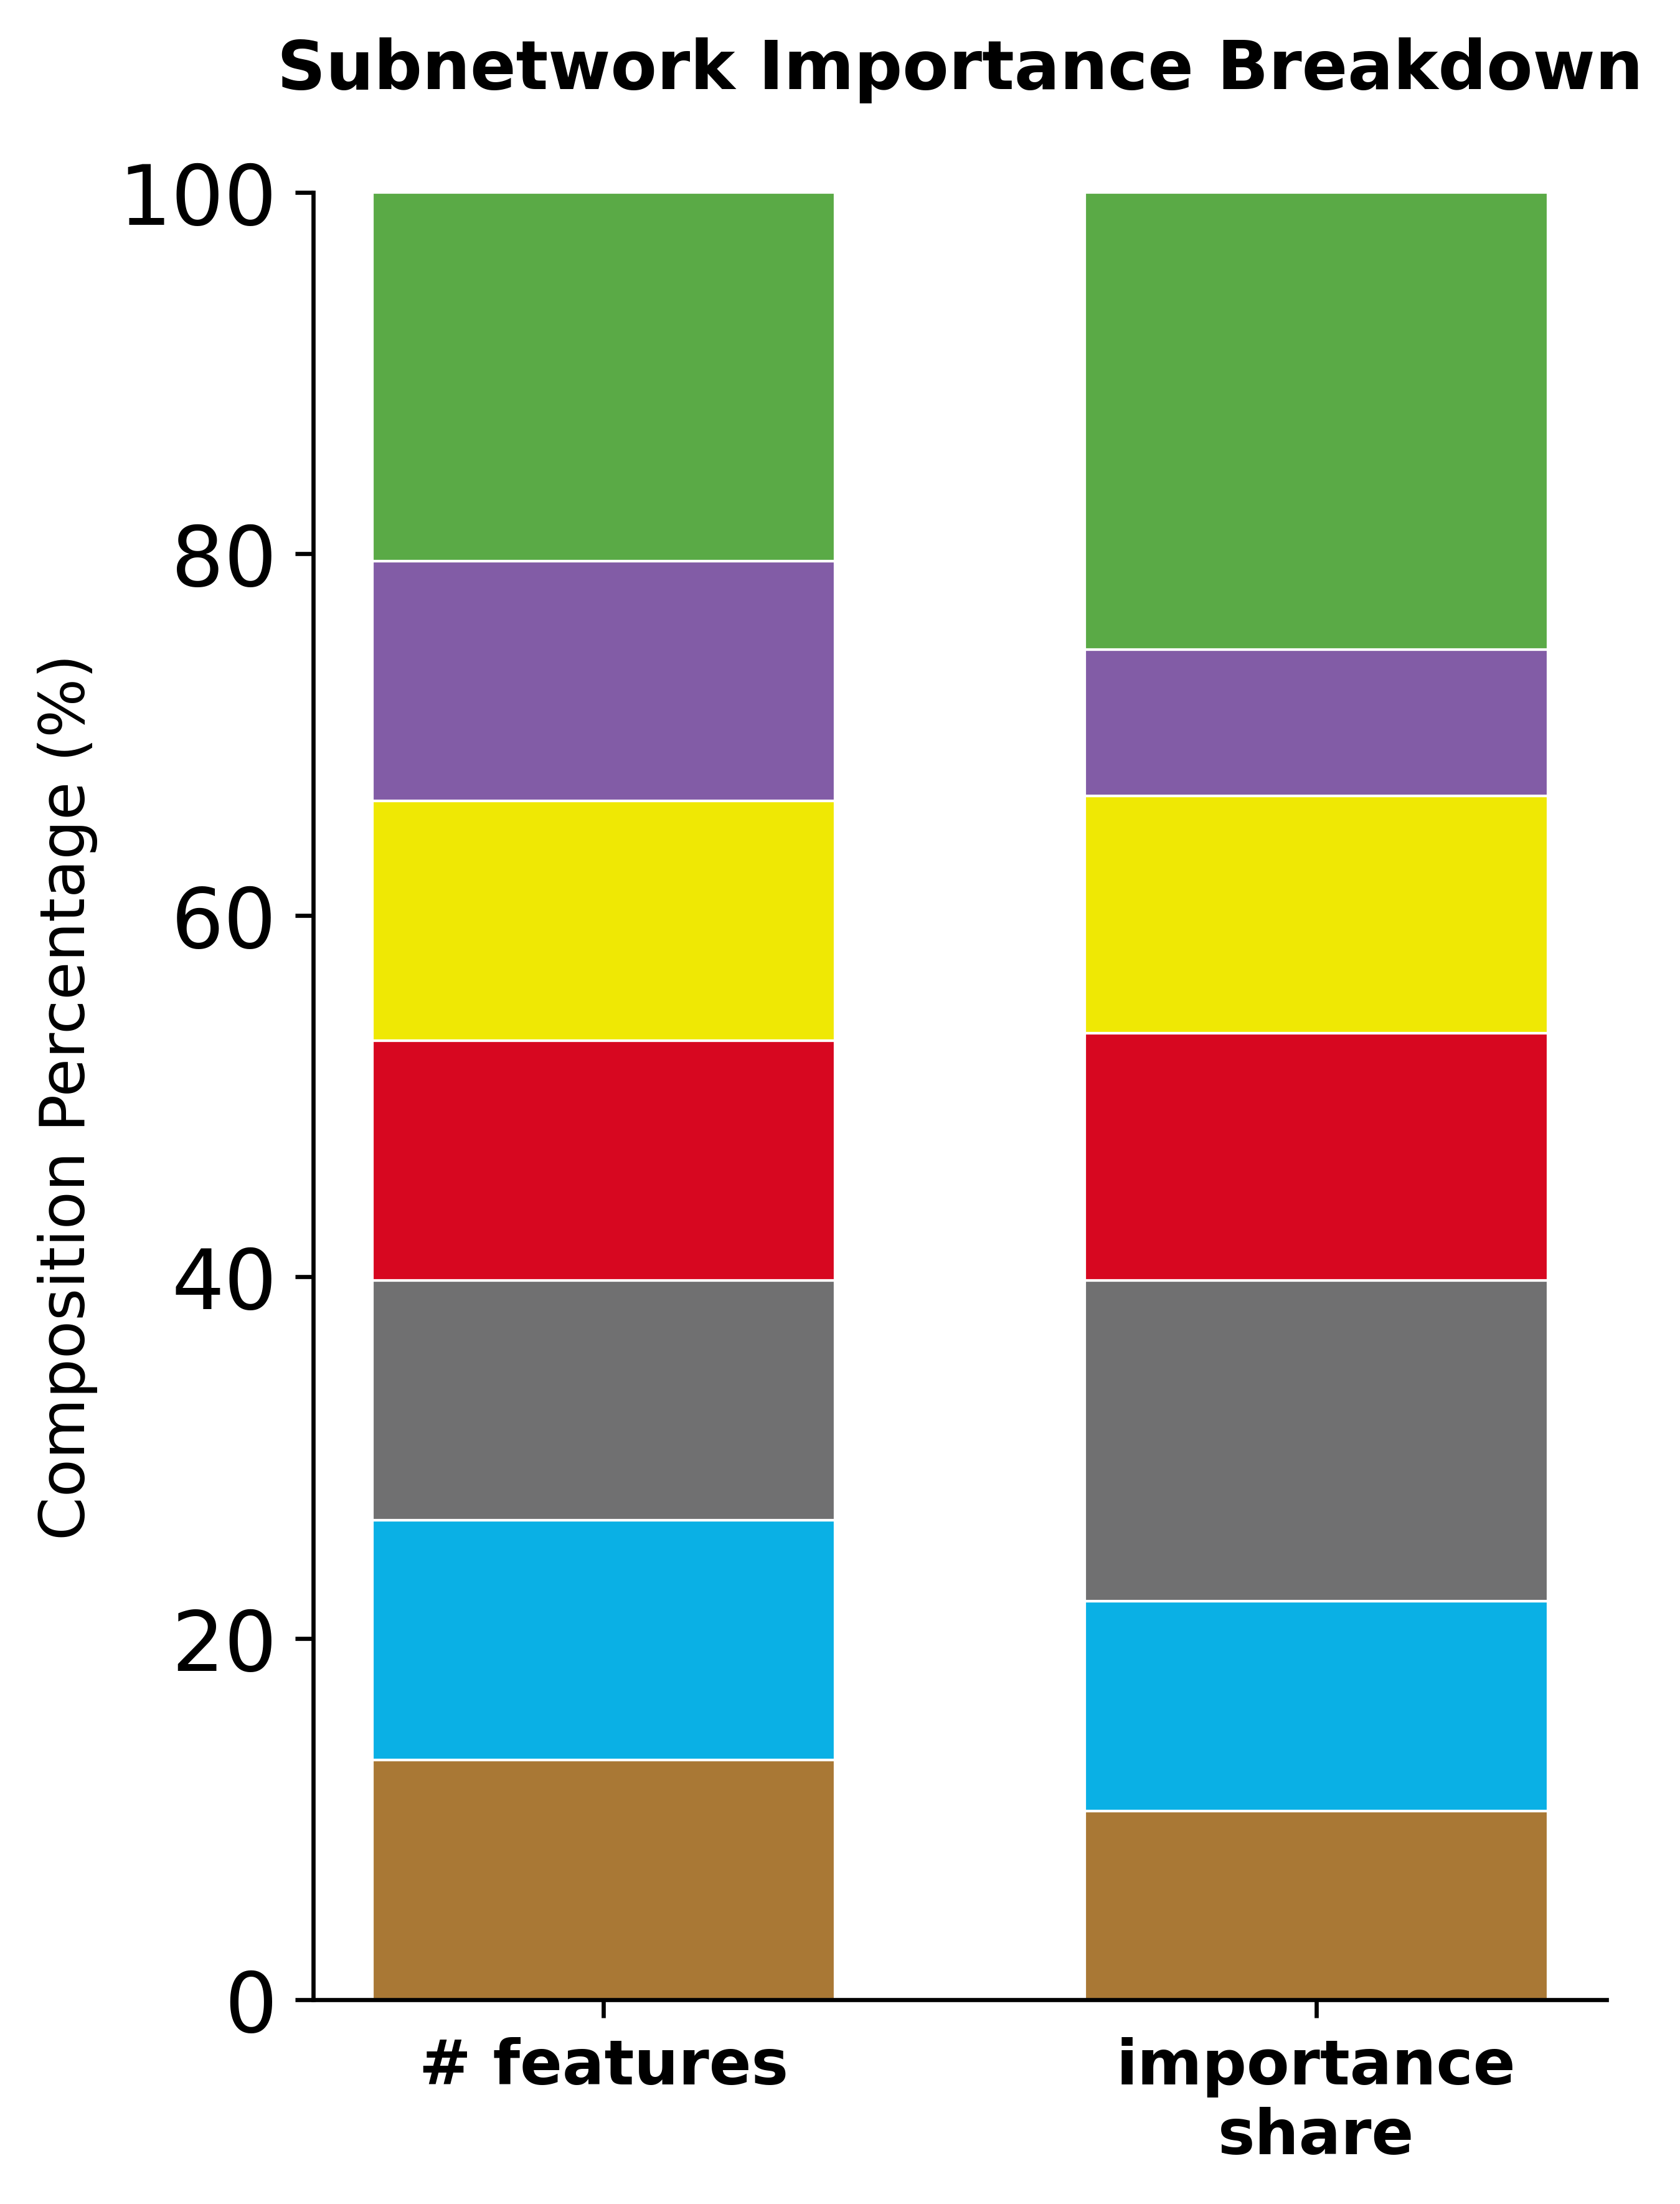

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Data Preparation
data = {
    'Category': [
        'Subnetwork 0 (Hydrophobic)', 
        'Subnetwork 1 (Polar)', 
        'Subnetwork 2 (Intermediate)', 
        'Subnetwork 3 (Charged)', 
        'Subnetwork 4 (Uncharged)', 
        'Subnetwork 5 (Flexible)', 
        'Inter-subnetwork'
    ],
    'Feature_Count': [39, 39, 39, 39, 39, 39, 60],
    'Importance_Share (%)': [10.4596, 11.6138, 17.7348, 13.6821, 13.1096, 8.1194, 25.2807]
}

df = pd.DataFrame(data)

# Calculate Percentage Share for Feature Count
df['Feature_Share (%)'] = (df['Feature_Count'] / df['Feature_Count'].sum()) * 100

# 2. Plotting Setup (PNAS Style)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['axes.linewidth'] = 0.8

fig, ax = plt.subplots(figsize=(4.5, 6), dpi=600)

# Assigned colors with 100% opacity (alpha=1.0 is default)
colors = [
    '#A97835', # Sub 0
    '#0AB0E5', # Sub 1
    '#707071', # Sub 2
    '#D70720', # Sub 3
    '#EFE804', # Sub 4
    '#825CA6', # Sub 5
    '#5AAA46'  # Inter
]

categories = df['Category'].tolist()
bar_width = 0.65
bottom_feat = 0
bottom_imp = 0

# 3. Construct Stacked Bars
for i, category in enumerate(categories):
    feat_val = df.loc[i, 'Feature_Share (%)']
    imp_val = df.loc[i, 'Importance_Share (%)']
    
    # Left Bar: Feature Quantity Share
    ax.bar(0, feat_val, bottom=bottom_feat, width=bar_width, color=colors[i], 
           edgecolor='white', linewidth=0.5, label=category, alpha=1.0)
    
    # Right Bar: Importance Contribution Share
    ax.bar(1, imp_val, bottom=bottom_imp, width=bar_width, color=colors[i], 
           edgecolor='white', linewidth=0.5, alpha=1.0)
    
    # Update stack bottoms
    bottom_feat += feat_val
    bottom_imp += imp_val

# 4. Styling and Aesthetics
ax.set_xticks([0, 1])
ax.set_xticklabels(['# features', 'importance\nshare'], 
                    fontsize=12, 
                    fontweight='bold', 
                    rotation=0, 
                    ha='center')

ax.set_ylabel('Composition Percentage (%)', fontsize=12)
ax.set_ylim(0, 100)
ax.tick_params(axis='y', labelsize=16)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add a professional title
plt.title('Subnetwork Importance Breakdown', fontsize=13, pad=20, fontweight='bold')

# External Legend
handles, labels = ax.get_legend_handles_labels()
#ax.legend(handles, labels, title='Properties', title_fontsize=10,bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)

plt.tight_layout()
# plt.savefig('subnetwork_breakdown_pnas.png', bbox_inches='tight')
plt.show()

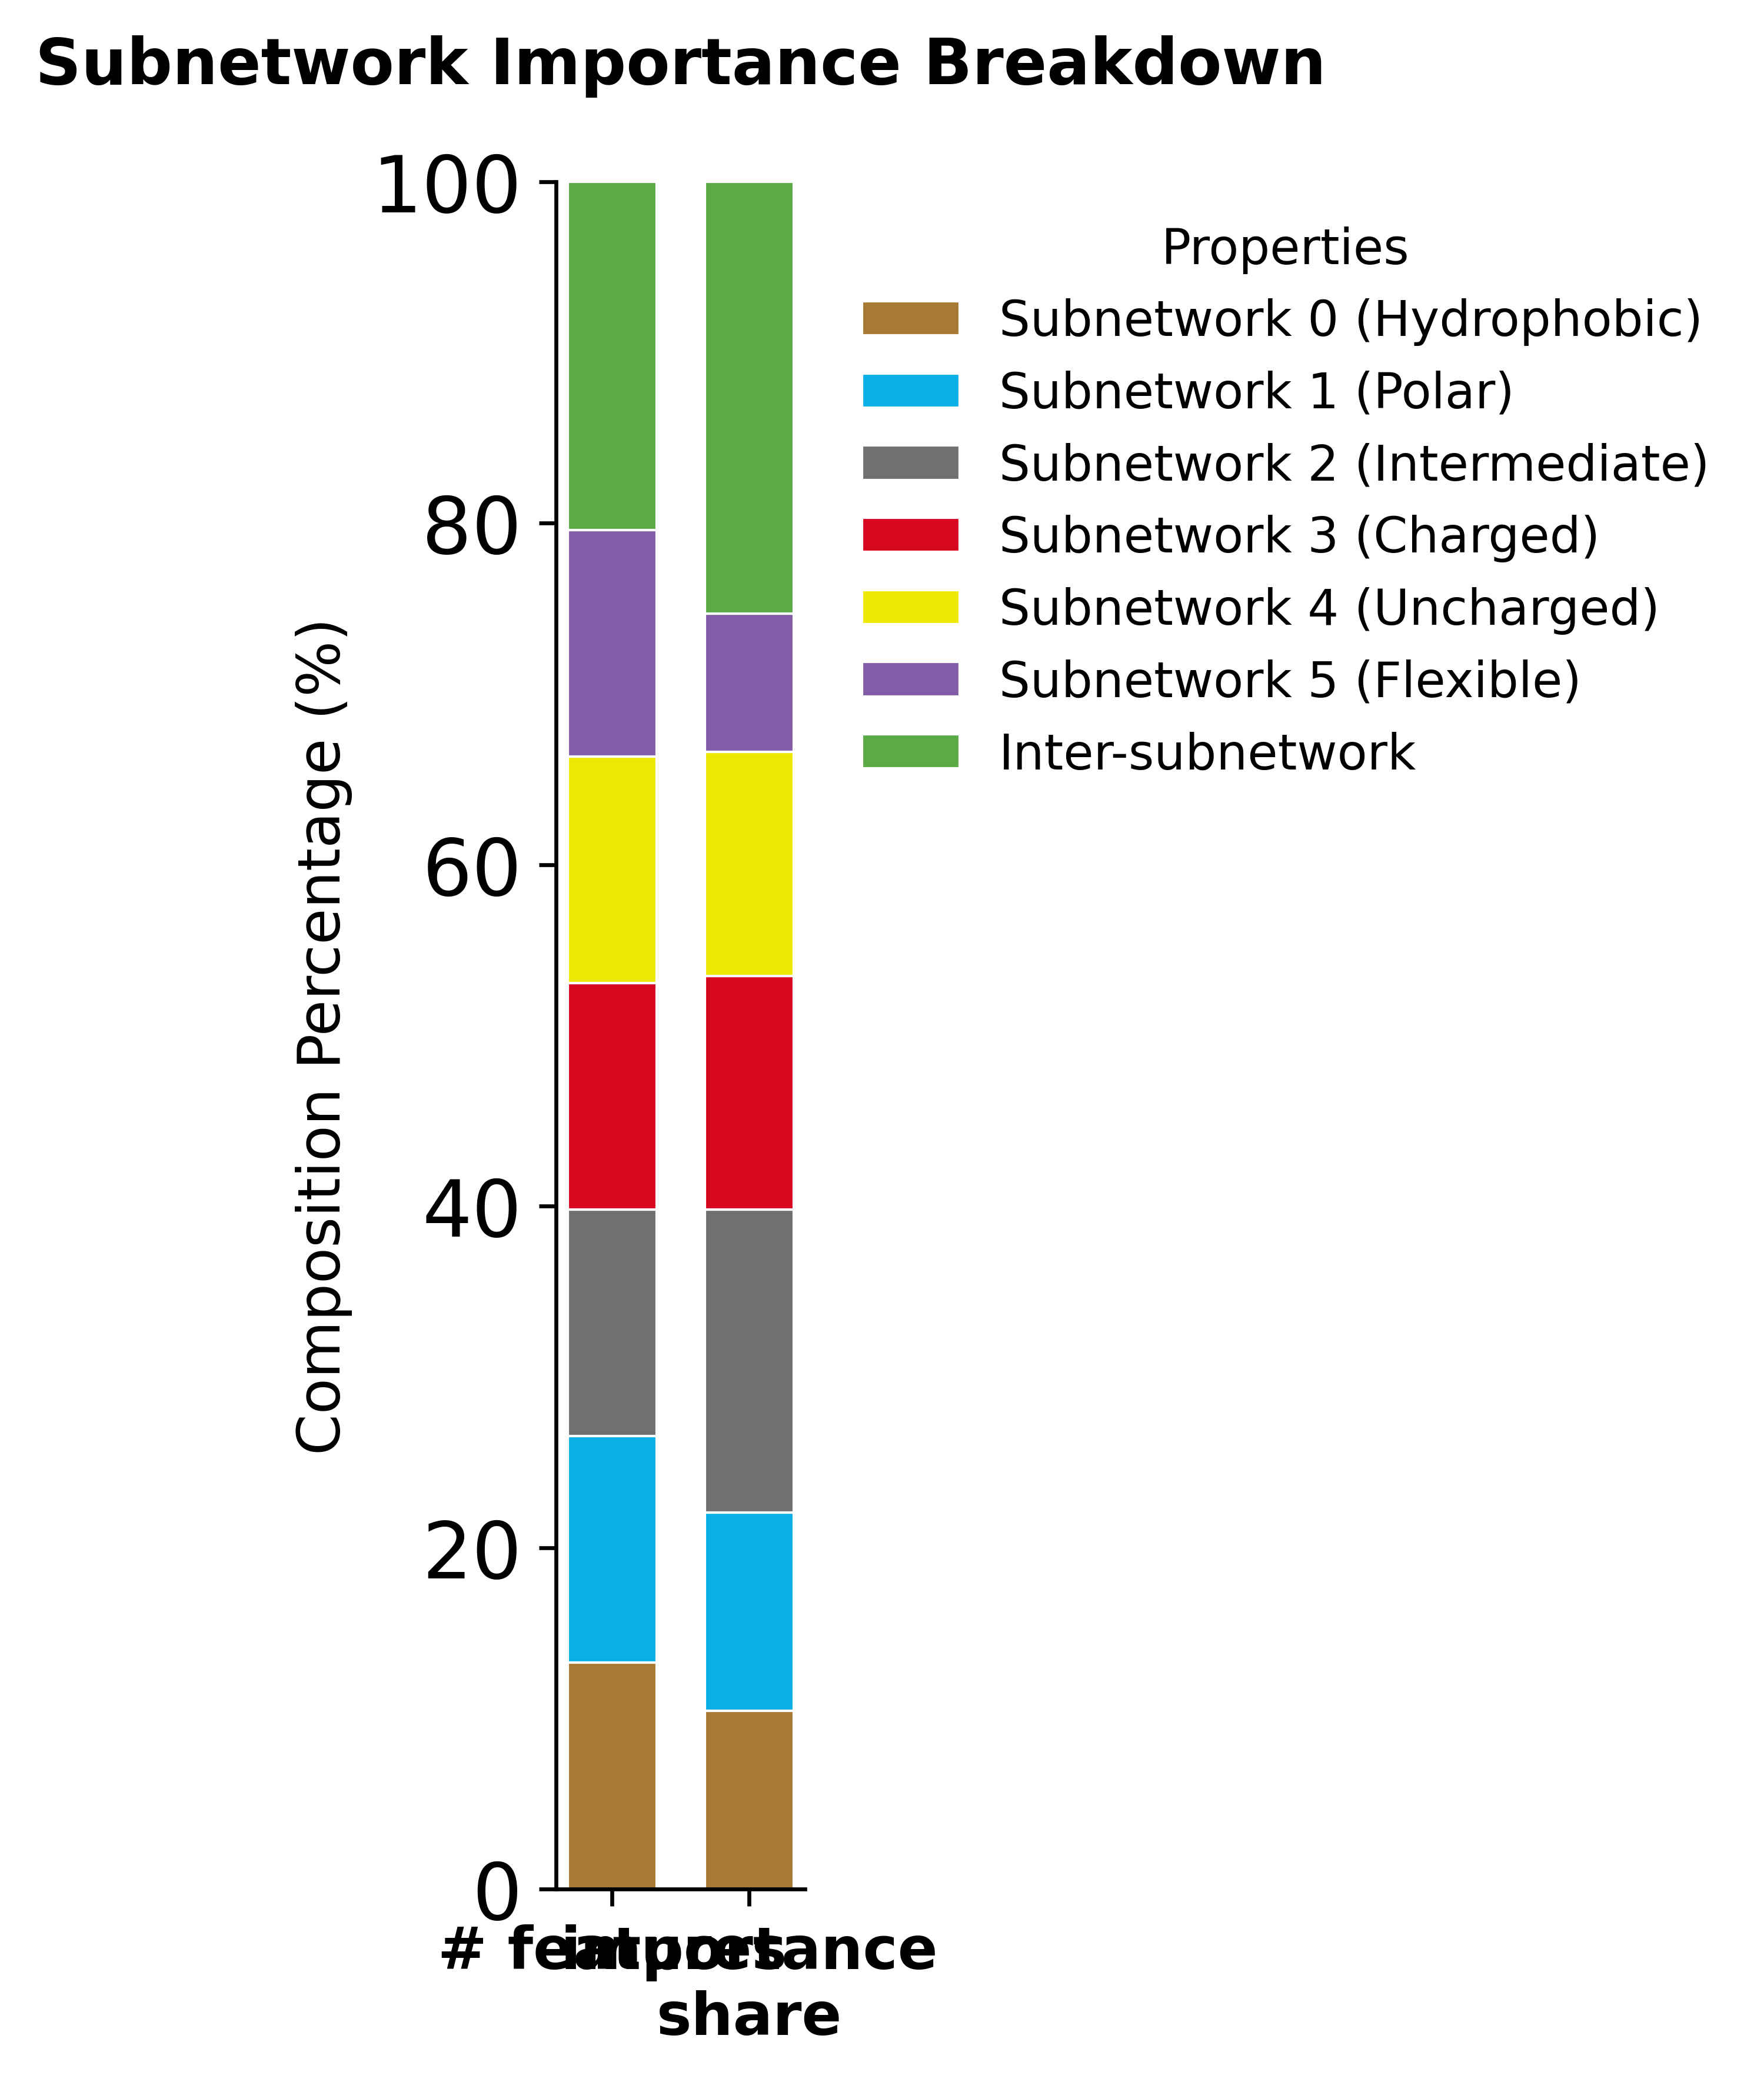

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Data Preparation
data = {
    'Category': [
        'Subnetwork 0 (Hydrophobic)', 
        'Subnetwork 1 (Polar)', 
        'Subnetwork 2 (Intermediate)', 
        'Subnetwork 3 (Charged)', 
        'Subnetwork 4 (Uncharged)', 
        'Subnetwork 5 (Flexible)', 
        'Inter-subnetwork'
    ],
    'Feature_Count': [39, 39, 39, 39, 39, 39, 60],
    'Importance_Share (%)': [10.4596, 11.6138, 17.7348, 13.6821, 13.1096, 8.1194, 25.2807]
}

df = pd.DataFrame(data)

# Calculate Percentage Share for Feature Count
df['Feature_Share (%)'] = (df['Feature_Count'] / df['Feature_Count'].sum()) * 100

# 2. Plotting Setup (PNAS Style)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['axes.linewidth'] = 0.8

fig, ax = plt.subplots(figsize=(4.5, 6), dpi=600)

# Assigned colors with 100% opacity (alpha=1.0 is default)
colors = [
    '#A97835', # Sub 0
    '#0AB0E5', # Sub 1
    '#707071', # Sub 2
    '#D70720', # Sub 3
    '#EFE804', # Sub 4
    '#825CA6', # Sub 5
    '#5AAA46'  # Inter
]

categories = df['Category'].tolist()
bar_width = 0.65
bottom_feat = 0
bottom_imp = 0

# 3. Construct Stacked Bars
for i, category in enumerate(categories):
    feat_val = df.loc[i, 'Feature_Share (%)']
    imp_val = df.loc[i, 'Importance_Share (%)']
    
    # Left Bar: Feature Quantity Share
    ax.bar(0, feat_val, bottom=bottom_feat, width=bar_width, color=colors[i], 
           edgecolor='white', linewidth=0.5, label=category, alpha=1.0)
    
    # Right Bar: Importance Contribution Share
    ax.bar(1, imp_val, bottom=bottom_imp, width=bar_width, color=colors[i], 
           edgecolor='white', linewidth=0.5, alpha=1.0)
    
    # Update stack bottoms
    bottom_feat += feat_val
    bottom_imp += imp_val

# 4. Styling and Aesthetics
ax.set_xticks([0, 1])
ax.set_xticklabels(['# features', 'importance\nshare'], 
                    fontsize=12, 
                    fontweight='bold', 
                    rotation=0, 
                    ha='center')

ax.set_ylabel('Composition Percentage (%)', fontsize=12)
ax.set_ylim(0, 100)
ax.tick_params(axis='y', labelsize=16)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add a professional title
plt.title('Subnetwork Importance Breakdown', fontsize=13, pad=20, fontweight='bold')

# External Legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title='Properties', title_fontsize=10,bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)

plt.tight_layout()
# plt.savefig('subnetwork_breakdown_pnas.png', bbox_inches='tight')
plt.show()